<a href="https://colab.research.google.com/github/02rrs/PortfolioProjects/blob/main/Project_Bazar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Stock Market Analysis for Banking Stocks**

In this project, we'll analyse data from the stock market for some Banking Stocks stocks.

We'll use Pandas to extract and analyse the information, visualise it, and look at different ways to analyse the risk of a stock, based on its performance history.

Here are the questions we'll try to answer:

What was the change in a stock's price over time?
What was the daily return average of a stock?
What was the moving average of various stocks?
What was the correlation between daily returns of different stocks?
How much value do we put at risk by investing in a particular stock?
How can we attempt to predict future stock behaviour?

In [ ]:
#Data Analysis import
import pandas as pd
from pandas import Series, DataFrame
import numpy as np
#Visualisation imports
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
%matplotlib inline

In [ ]:
import yfinance as yf
import pandas as pd

# Define your list of stocks (example)
bank_list = ["HDFCBANK.NS", "ICICIBANK.NS", "AXISBANK.NS"]  # Add Indian stock symbols here

# Define the start and end dates for fetching data
start = "2023-01-01"
end = "2024-12-01"

# Using a dictionary to store stock data
stock_data = {}

# Fetching data for each stock in the list
for stock in bank_list:
    stock_data[stock] = yf.download(stock, start=start, end=end)  # Download stock data


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Example: Displaying data for HDFC Bank in the desired format
hdfc_data = stock_data["HDFCBANK.NS"]

# Selecting only relevant columns and renaming them if necessary
hdfc_data = hdfc_data[['High', 'Low', 'Open', 'Close', 'Volume', 'Adj Close']]

print(hdfc_data.head())

Price                             High          Low         Open        Close  \
Ticker                     HDFCBANK.NS  HDFCBANK.NS  HDFCBANK.NS  HDFCBANK.NS   
Date                                                                            
2023-01-02 00:00:00+00:00  1639.750000  1618.550049  1627.000000  1628.699951   
2023-01-03 00:00:00+00:00  1643.000000  1622.199951  1622.199951  1639.349976   
2023-01-04 00:00:00+00:00  1645.750000  1607.000000  1635.000000  1610.050049   
2023-01-05 00:00:00+00:00  1618.050049  1589.400024  1615.000000  1599.699951   
2023-01-06 00:00:00+00:00  1609.099976  1578.199951  1602.000000  1594.400024   

Price                          Volume    Adj Close  
Ticker                    HDFCBANK.NS  HDFCBANK.NS  
Date                                                
2023-01-02 00:00:00+00:00     2190689  1588.541748  
2023-01-03 00:00:00+00:00     4189015  1598.929077  
2023-01-04 00:00:00+00:00     5175800  1570.351685  
2023-01-05 00:00:00+00:00     547

In [ ]:
hdfc_data.describe()

Price,High,Low,Open,Close,Volume,Adj Close
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
count,470.000000,470.000000,470.000000,470.000000,4.700000e+02,470.000000
mean,1613.267551,1588.061065,1600.693298,1600.397450,1.894257e+07,1581.961259
std,90.651967,89.326536,90.743318,89.998468,1.694664e+07,92.635436
min,1391.500000,1363.550049,1376.000000,1384.050049,8.798460e+05,1365.404785
25%,1540.824951,1520.950012,1531.937500,1531.075012,1.190491e+07,1512.052246
50%,1634.000000,1604.825012,1619.799988,1617.200012,1.610101e+07,1601.678345
75%,1672.550049,1647.037537,1660.000000,1659.487488,2.160326e+07,1638.420532
max,1836.099976,1788.000000,1819.000000,1812.300049,2.226710e+08,1812.300049


In [ ]:
hdfc_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 470 entries, 2023-01-02 00:00:00+00:00 to 2024-11-29 00:00:00+00:00
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   (High, HDFCBANK.NS)       470 non-null    float64
 1   (Low, HDFCBANK.NS)        470 non-null    float64
 2   (Open, HDFCBANK.NS)       470 non-null    float64
 3   (Close, HDFCBANK.NS)      470 non-null    float64
 4   (Volume, HDFCBANK.NS)     470 non-null    int64  
 5   (Adj Close, HDFCBANK.NS)  470 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 25.7 KB


<Axes: xlabel='Date'>

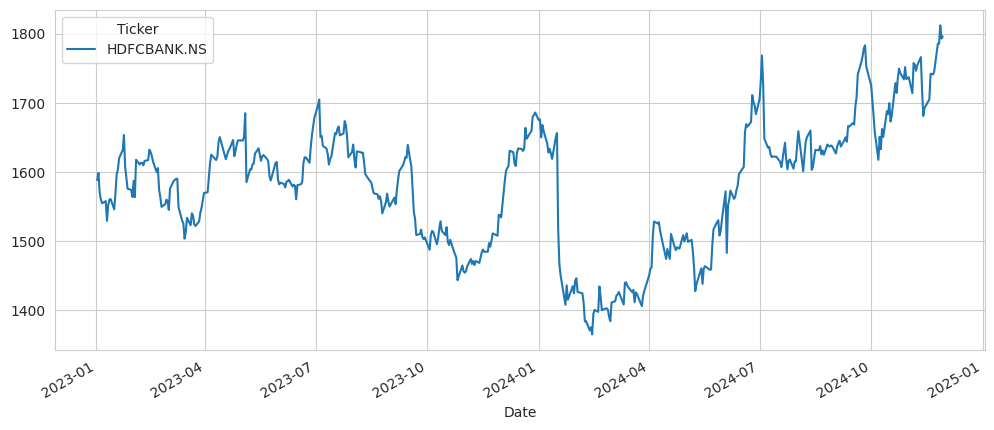

In [ ]:
#Now we'll see what's the change if stock price over time
#Plotting the stock's adjusted closing price using pandas
hdfc_data['Adj Close'].plot(legend=True,figsize=(12,5))

<Axes: xlabel='Date'>

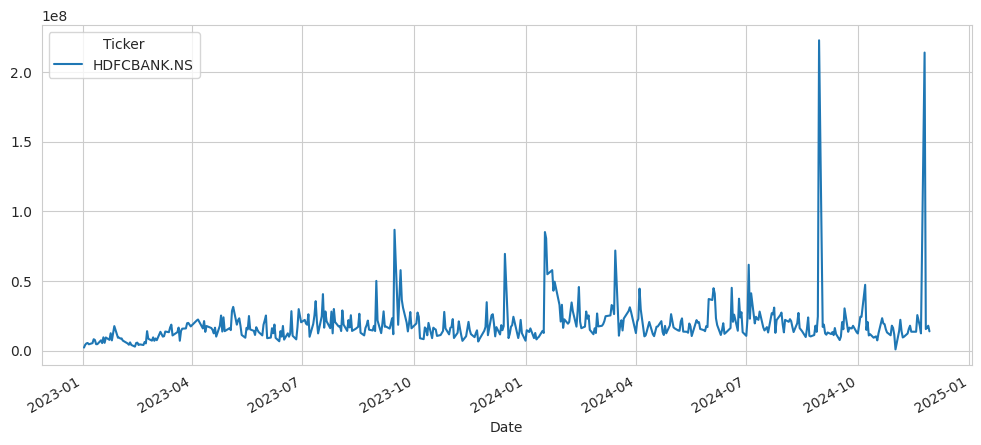

In [ ]:
#Change in stock's volume begin traded overtime
hdfc_data['Volume'].plot(legend=True,figsize=(12,5))

In [ ]:
#Let's check out the moving average for stocks over a 10, 20 and 50 day period of time. We'll add that information to the stock's dataframe.

ma_day = [10,20,50]

for ma in ma_day:
    column_name = "MA for %s days" %(str(ma))
    hdfc_data[column_name] = hdfc_data['Adj Close'].rolling(window = ma, center = False).mean()

<ipython-input-12-4f3fb3aa91db>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdfc_data[column_name] = hdfc_data['Adj Close'].rolling(window = ma, center = False).mean()
<ipython-input-12-4f3fb3aa91db>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdfc_data[column_name] = hdfc_data['Adj Close'].rolling(window = ma, center = False).mean()
<ipython-input-12-4f3fb3aa91db>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [ ]:
hdfc_data.tail()

Price,High,Low,Open,Close,Volume,Adj Close,MA for 10 days,MA for 20 days,MA for 50 days
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,,,
Date,,,,,,,,,
2024-11-25 00:00:00+00:00,1803.550049,1764.900024,1785.050049,1785.599976,213868637,1785.599976,1733.279980,1737.179987,1715.448999
2024-11-26 00:00:00+00:00,1810.000000,1769.800049,1810.000000,1785.550049,15467783,1785.550049,1736.389990,1739.287488,1717.828000
2024-11-27 00:00:00+00:00,1817.349976,1785.150024,1789.900024,1812.300049,16357488,1812.300049,1740.989990,1743.192493,1720.755002
2024-11-28 00:00:00+00:00,1836.099976,1788.000000,1819.000000,1793.150024,17861196,1793.150024,1748.484998,1745.257495,1723.199004
2024-11-29 00:00:00+00:00,1804.599976,1782.900024,1801.300049,1796.050049,13834768,1796.050049,1759.955005,1748.329999,1725.744004


<Axes: xlabel='Date'>

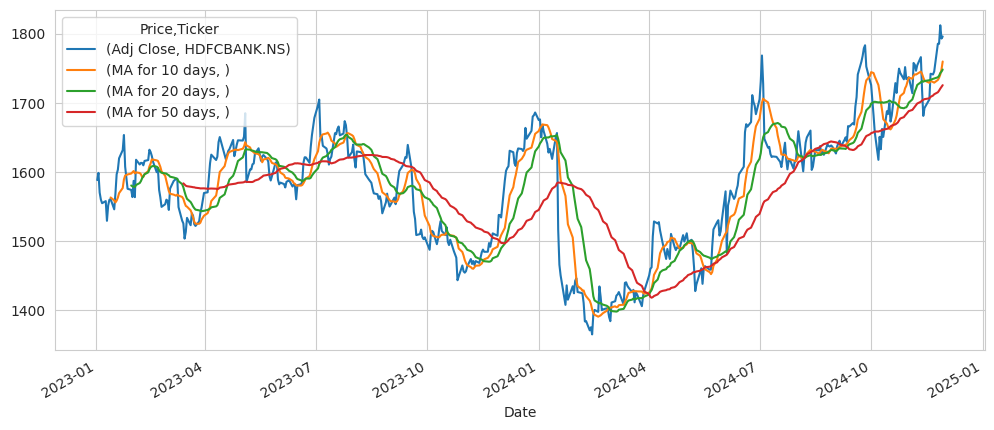

In [ ]:
hdfc_data[['Adj Close','MA for 10 days','MA for 20 days','MA for 50 days']].plot(subplots=False,figsize=(12,5))

In [ ]:
# Now we''ll check daily return of Stock
hdfc_data['Daily Return'] = hdfc_data['Adj Close'].pct_change()

<ipython-input-15-86326ad7036c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hdfc_data['Daily Return'] = hdfc_data['Adj Close'].pct_change()


In [ ]:
hdfc_data['Daily Return'].tail()

,Daily Return
Date,
2024-11-25 00:00:00+00:00,0.022915
2024-11-26 00:00:00+00:00,-0.000028
2024-11-27 00:00:00+00:00,0.014981
2024-11-28 00:00:00+00:00,-0.010567
2024-11-29 00:00:00+00:00,0.001617


<Axes: xlabel='Date'>

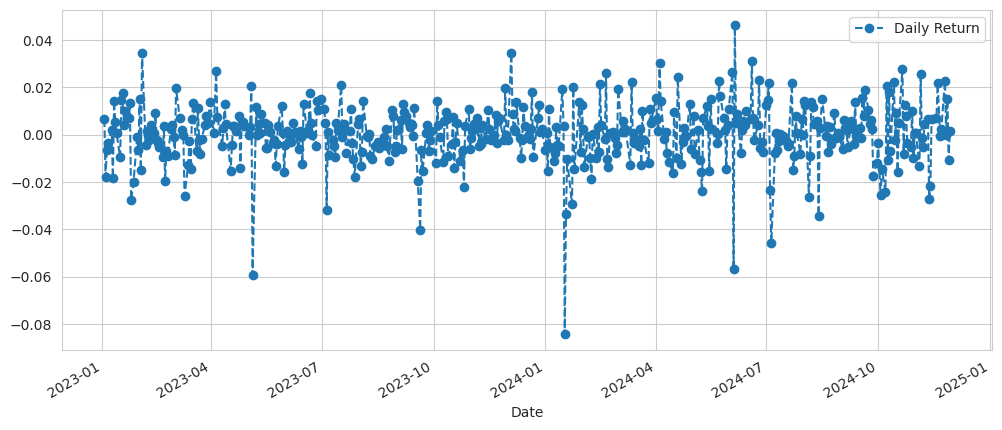

In [ ]:
hdfc_data['Daily Return'].plot(figsize=(12,5),legend=True,linestyle='--',marker='o')

<Axes: xlabel='Daily Return', ylabel='Count'>

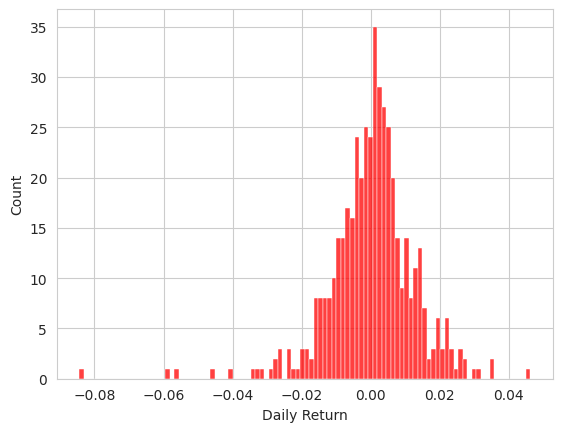

In [ ]:
sns.histplot(x=hdfc_data['Daily Return'].dropna(),bins=100,color='red')

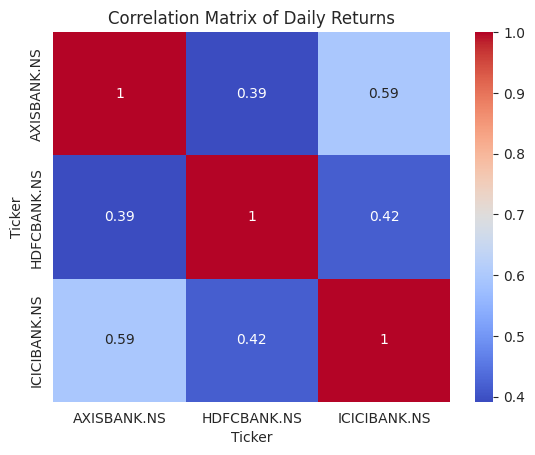

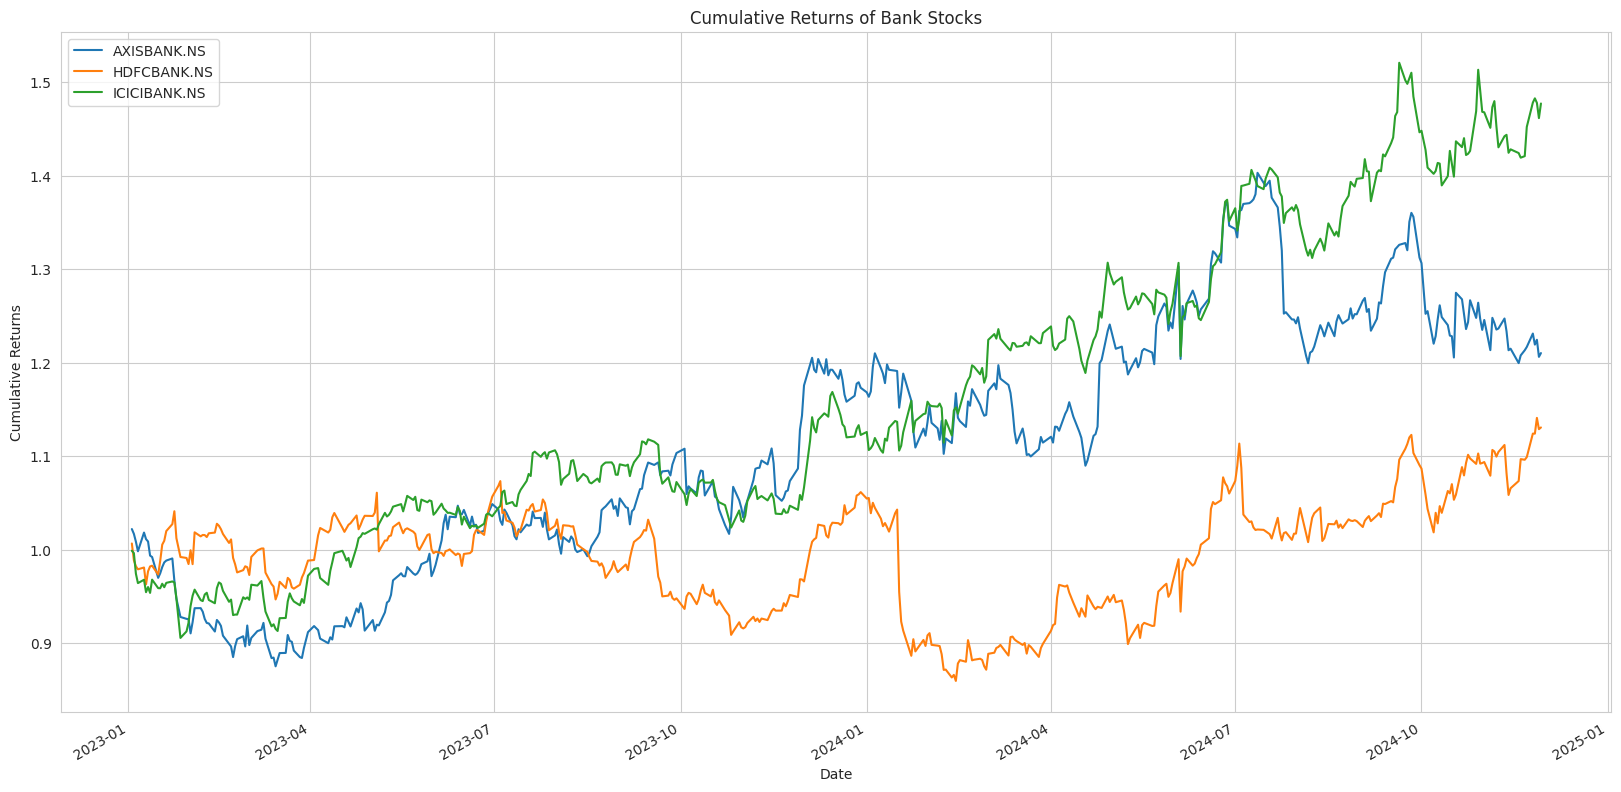

In [ ]:
# prompt: Above code error free

# Assuming you have the DataFrame 'close_df' defined as in your code snippet
# Let's calculate the daily returns for all stocks in 'close_df'
daily_returns_df = close_df.pct_change()

# Now, we can plot the correlation matrix as a heatmap
sns.heatmap(daily_returns_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Daily Returns')
plt.show()

# Calculate the cumulative returns for each stock
cumulative_returns_df = (1 + daily_returns_df).cumprod()

# Plot the cumulative returns
cumulative_returns_df.plot(figsize=(20, 10))
plt.title('Cumulative Returns of Bank Stocks')
plt.ylabel('Cumulative Returns')
plt.xlabel('Date')
plt.legend()
plt.show()

In [ ]:
import yfinance as yf
import datetime
close_df = yf.download(bank_list, start, end)['Adj Close']

[*********************100%***********************]  3 of 3 completed


In [ ]:
close_df.tail()

Ticker,AXISBANK.NS,HDFCBANK.NS,ICICIBANK.NS
Date,,,
2024-11-25 00:00:00+00:00,1155.900024,1785.599976,1300.949951
2024-11-26 00:00:00+00:00,1144.800049,1785.550049,1304.949951
2024-11-27 00:00:00+00:00,1149.650024,1812.300049,1300.699951
2024-11-28 00:00:00+00:00,1132.500000,1793.150024,1286.349976
2024-11-29 00:00:00+00:00,1136.300049,1796.050049,1300.099976


In [ ]:
#we can use Pandas' pct_change method to get the daily returns of our stocks.
rets_df = close_df.pct_change()
rets_df.tail()

Ticker,AXISBANK.NS,HDFCBANK.NS,ICICIBANK.NS
Date,,,
2024-11-25 00:00:00+00:00,0.011817,0.022915,0.017918
2024-11-26 00:00:00+00:00,-0.009603,-0.000028,0.003075
2024-11-27 00:00:00+00:00,0.004237,0.014981,-0.003257
2024-11-28 00:00:00+00:00,-0.014918,-0.010567,-0.011033
2024-11-29 00:00:00+00:00,0.003355,0.001617,0.010689


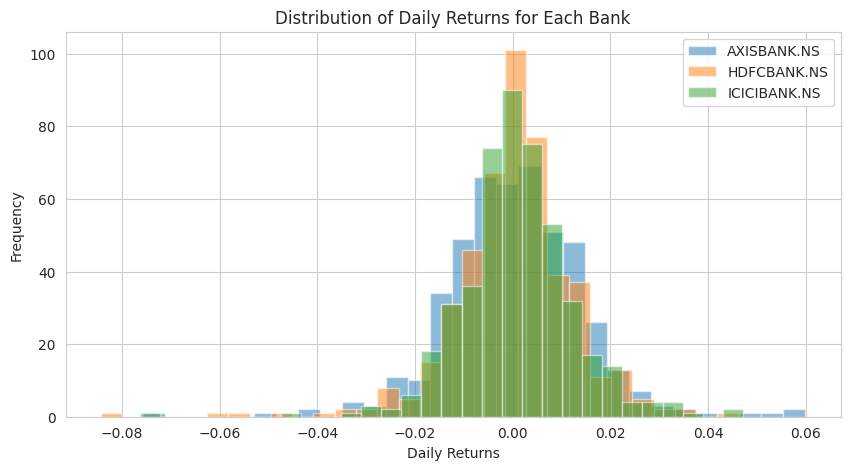

In [ ]:
# @title Distribution of Daily Returns for Each Bank

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(rets_df['AXISBANK.NS'], bins=30, alpha=0.5, label='AXISBANK.NS')
plt.hist(rets_df['HDFCBANK.NS'], bins=30, alpha=0.5, label='HDFCBANK.NS')
plt.hist(rets_df['ICICIBANK.NS'], bins=30, alpha=0.5, label='ICICIBANK.NS')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.title('Distribution of Daily Returns for Each Bank')
_ = plt.legend()

Let's try creating a scatterplot to visualise any correlations between different stocks. First we'll visualise a scatterplot for the relationship between the daily return of a stock to itself.

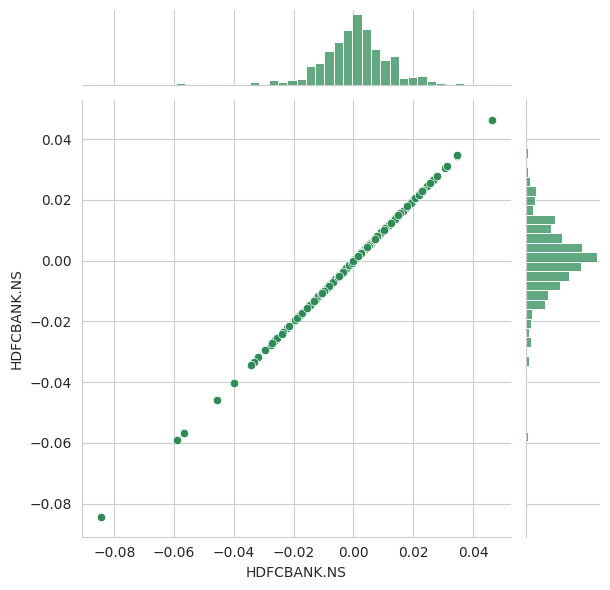

In [ ]:
sns.jointplot(x='HDFCBANK.NS',y='HDFCBANK.NS',data=rets_df,kind='scatter',color='seagreen')

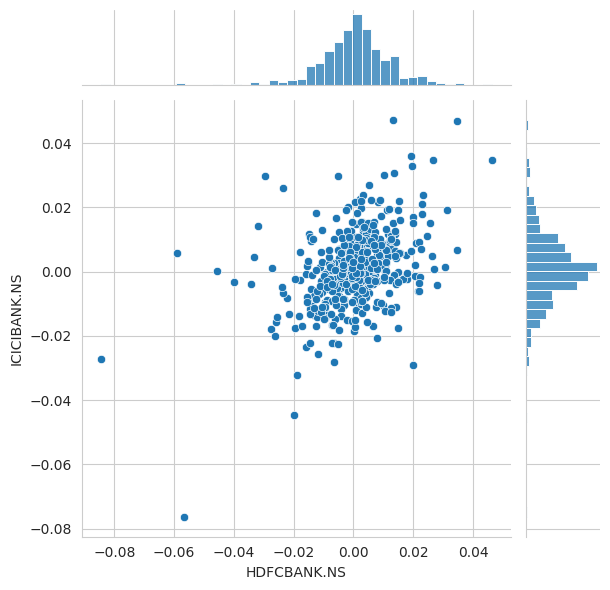

In [ ]:
#As expected, the relationship is perfectly linear because we're trying to correlate something with itself. Now, let's check out the relationship between HDFC Bank and Icici Bank's daily returns.

sns.jointplot(x='HDFCBANK.NS',y='ICICIBANK.NS',data=rets_df,kind='scatter')

Risk Analysis:

There are many ways we can quantify risk, one of the most basic ways using the information we've gathered on daily percentage returns is by comparing the expected return with the standard deviation of the daily returns.

In [ ]:
# Let's start by defining a new DataFrame as a clenaed version of the orignal bank_returns DataFrame
